# ConditionalGlow Evaluation Results

Visualization of generated hyperspectral images and FID scores from the trained ConditionalGlow model (epoch 210, NLL=-7.8869).

**Model**: ConditionalGlow (3 scales × 4 steps, 256 hidden channels)  
**Data**: 128×128×125 hyperspectral crop disease images, 10 severity classes  
**Best temperature**: 1.05 (all classes)  
**Metrics**: Spectral FID (624-dim) and Spatial FID (32×32 downsample + PCA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# Paths (relative to notebooks/)
DATA_DIR = Path("../data")
RESULTS_DIR = Path("../results/eval")
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load FID results
fid_df = pd.read_csv(RESULTS_DIR / "submission.csv")
print(fid_df.to_string(index=False))
print(f"\nMean Spectral FID: {fid_df['spectral_fid'].mean():.2f}")
print(f"Mean Spatial FID:  {fid_df['spatial_fid'].mean():.2f}")

# Stats for denormalization
stats = np.load(DATA_DIR / "processed" / "stats.npz")
global_min = float(stats["global_min"])
global_max = float(stats["global_max"])

 class  spectral_fid  spatial_fid  temperature
     0        0.3103     132.7493         1.05
     1        2.0304      98.7838         1.05
     2        0.2720     117.3953         1.05
     3        3.0910     115.4306         1.05
     4        1.8753     121.5503         1.05
     5        1.3394      92.5382         1.05
     6        1.3244      99.6250         1.05
     7        1.4094      87.8454         1.05
     8        2.4663      77.1198         1.05
     9        0.2661     116.0910         1.05

Mean Spectral FID: 1.44
Mean Spatial FID:  105.91


## 1. FID Scores by Class

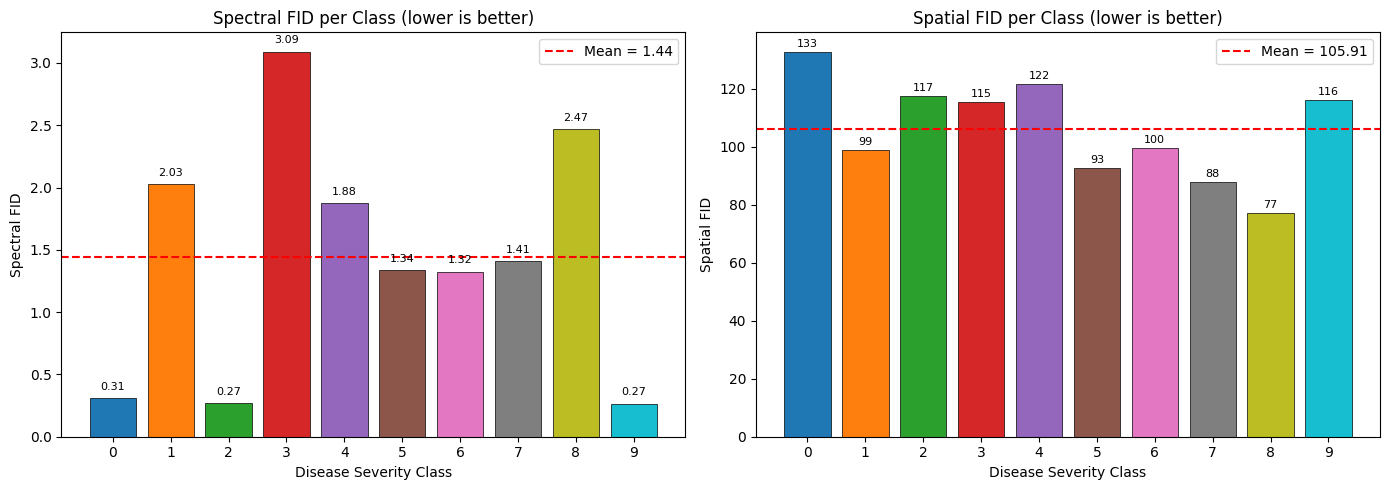

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes = fid_df["class"].values
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Spectral FID
bars1 = axes[0].bar(classes, fid_df["spectral_fid"], color=colors, edgecolor="black", linewidth=0.5)
axes[0].axhline(fid_df["spectral_fid"].mean(), color="red", linestyle="--", label=f'Mean = {fid_df["spectral_fid"].mean():.2f}')
axes[0].set_xlabel("Disease Severity Class")
axes[0].set_ylabel("Spectral FID")
axes[0].set_title("Spectral FID per Class (lower is better)")
axes[0].set_xticks(range(10))
axes[0].legend()
for bar, val in zip(bars1, fid_df["spectral_fid"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=8)

# Spatial FID
bars2 = axes[1].bar(classes, fid_df["spatial_fid"], color=colors, edgecolor="black", linewidth=0.5)
axes[1].axhline(fid_df["spatial_fid"].mean(), color="red", linestyle="--", label=f'Mean = {fid_df["spatial_fid"].mean():.2f}')
axes[1].set_xlabel("Disease Severity Class")
axes[1].set_ylabel("Spatial FID")
axes[1].set_title("Spatial FID per Class (lower is better)")
axes[1].set_xticks(range(10))
axes[1].legend()
for bar, val in zip(bars2, fid_df["spatial_fid"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fid_scores_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Temperature Sweep (Spectral FID)

Per-class spectral FID across temperatures 0.90–1.20 (from the evaluation run). All classes converged to optimal temperature = 1.05.

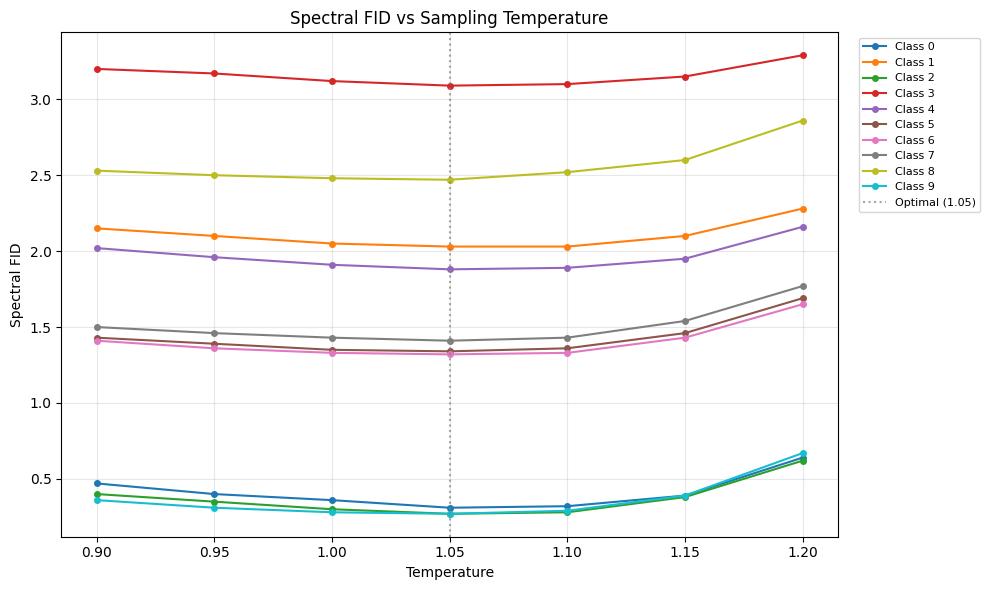

In [3]:
# Temperature sweep data from Kaggle evaluation output
temperatures = [0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20]
sweep_data = {
    0: [0.47, 0.40, 0.36, 0.31, 0.32, 0.39, 0.64],
    1: [2.15, 2.10, 2.05, 2.03, 2.03, 2.10, 2.28],
    2: [0.40, 0.35, 0.30, 0.27, 0.28, 0.38, 0.62],
    3: [3.20, 3.17, 3.12, 3.09, 3.10, 3.15, 3.29],
    4: [2.02, 1.96, 1.91, 1.88, 1.89, 1.95, 2.16],
    5: [1.43, 1.39, 1.35, 1.34, 1.36, 1.46, 1.69],
    6: [1.41, 1.36, 1.33, 1.32, 1.33, 1.43, 1.65],
    7: [1.50, 1.46, 1.43, 1.41, 1.43, 1.54, 1.77],
    8: [2.53, 2.50, 2.48, 2.47, 2.52, 2.60, 2.86],
    9: [0.36, 0.31, 0.28, 0.27, 0.29, 0.39, 0.67],
}

fig, ax = plt.subplots(figsize=(10, 6))
for cls in range(10):
    ax.plot(temperatures, sweep_data[cls], marker="o", markersize=4, label=f"Class {cls}")

ax.axvline(1.05, color="gray", linestyle=":", alpha=0.7, label="Optimal (1.05)")
ax.set_xlabel("Temperature")
ax.set_ylabel("Spectral FID")
ax.set_title("Spectral FID vs Sampling Temperature")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "temperature_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Real vs Generated Sample Images

Displaying false-color RGB composites (bands 60, 30, 10 mapped to R, G, B) for visual comparison.

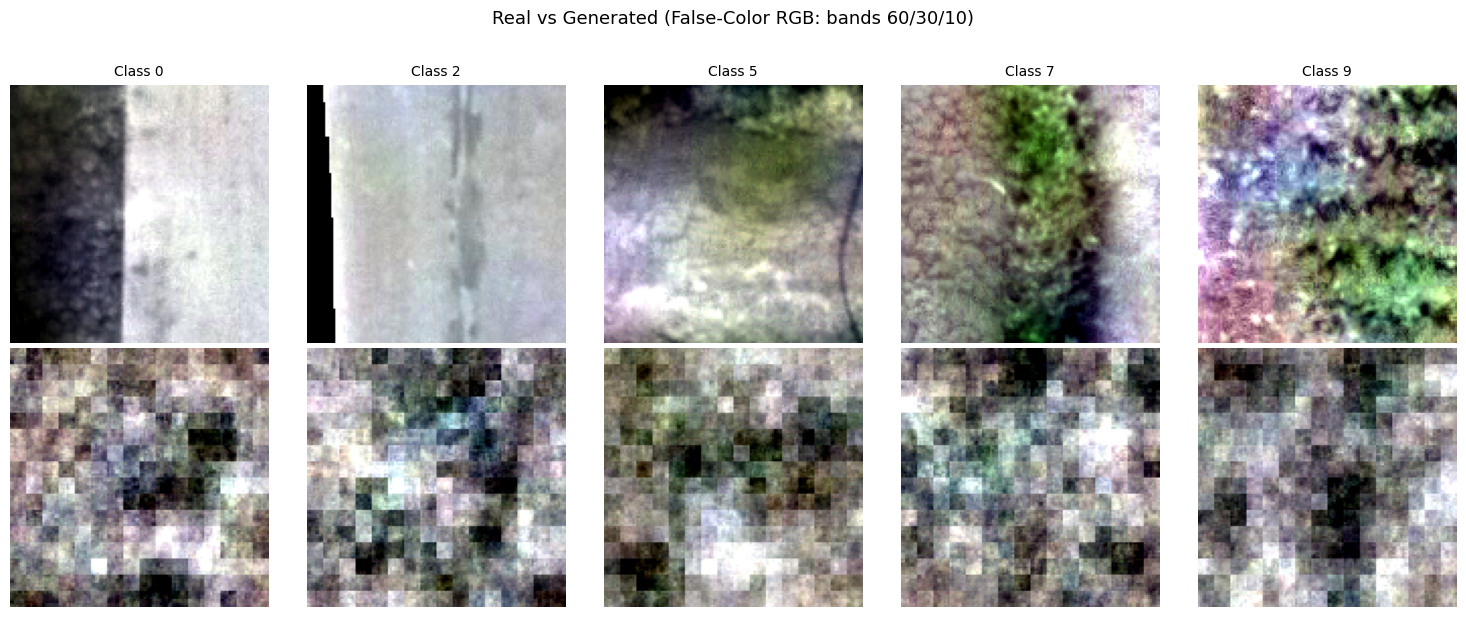

In [4]:
def load_image_normalized(path):
    """Load .npy and normalize to [0,1] float32."""
    arr = np.load(path).astype(np.float32)
    if arr.max() > 1.5:  # raw uint16
        arr = (arr - global_min) / (global_max - global_min + 1e-8)
    return np.clip(arr, 0, 1)


def make_rgb(img, bands=(60, 30, 10)):
    """Create false-color RGB from 3 spectral bands."""
    rgb = np.stack([img[:, :, b] for b in bands], axis=-1)
    # Per-channel contrast stretch to [0, 1]
    for c in range(3):
        lo, hi = np.percentile(rgb[:, :, c], [2, 98])
        if hi - lo > 1e-6:
            rgb[:, :, c] = np.clip((rgb[:, :, c] - lo) / (hi - lo), 0, 1)
    return rgb


# Show 2 samples per class: top row = real, bottom row = generated
classes_to_show = [0, 2, 5, 7, 9]  # representative subset
n_show = len(classes_to_show)

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))

for col, cls in enumerate(classes_to_show):
    # Real image
    real_dir = DATA_DIR / "evaluation" / str(cls)
    real_files = sorted(real_dir.glob("*.npy"))
    real_img = load_image_normalized(real_files[0])
    axes[0, col].imshow(make_rgb(real_img))
    axes[0, col].set_title(f"Class {cls}", fontsize=10)
    axes[0, col].axis("off")

    # Generated image
    gen_dir = RESULTS_DIR / "generated" / str(cls)
    gen_files = sorted(gen_dir.glob("*.npy"))
    gen_img = load_image_normalized(gen_files[0])
    axes[1, col].imshow(make_rgb(gen_img))
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Real", fontsize=12, rotation=0, labelpad=40, va="center")
axes[1, 0].set_ylabel("Generated", fontsize=12, rotation=0, labelpad=40, va="center")

plt.suptitle("Real vs Generated (False-Color RGB: bands 60/30/10)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "real_vs_generated_samples.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Spectral Profile Comparison

Mean spectral signature (across all pixels) for real vs generated images, per class. This is the most important metric for hyperspectral data — it shows whether the model captures the characteristic absorption/reflection patterns of each disease severity level.

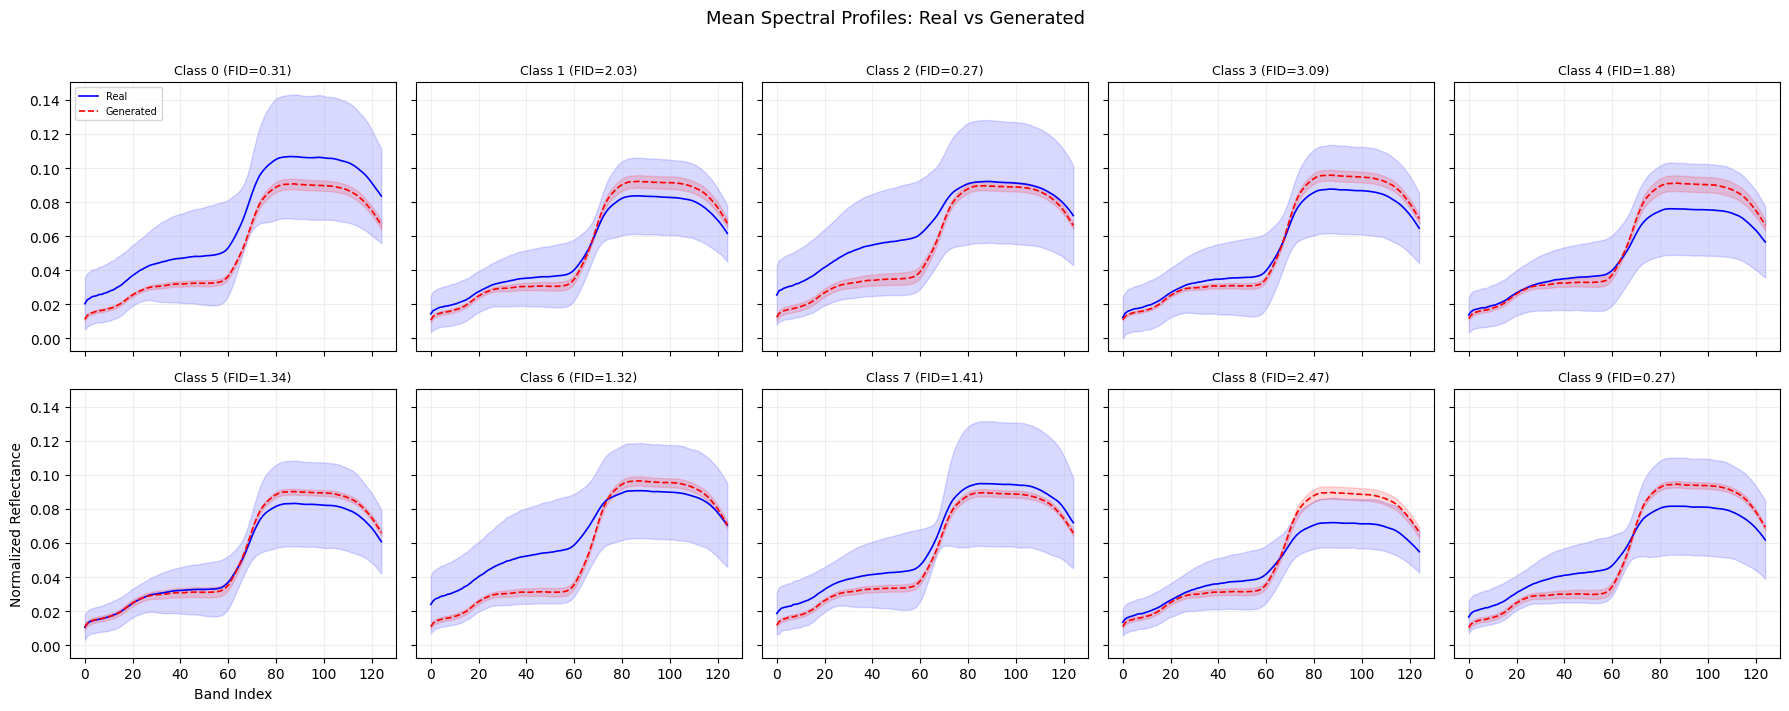

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
bands = np.arange(125)

for cls in range(10):
    ax = axes[cls // 5, cls % 5]

    # Real: load up to 10 images for mean spectrum
    real_dir = DATA_DIR / "evaluation" / str(cls)
    real_files = sorted(real_dir.glob("*.npy"))[:10]
    real_spectra = []
    for f in real_files:
        img = load_image_normalized(f)
        real_spectra.append(img.mean(axis=(0, 1)))  # mean over spatial dims -> (125,)
    real_mean = np.mean(real_spectra, axis=0)
    real_std = np.std(real_spectra, axis=0)

    # Generated: load up to 10 images
    gen_dir = RESULTS_DIR / "generated" / str(cls)
    gen_files = sorted(gen_dir.glob("*.npy"))[:10]
    gen_spectra = []
    for f in gen_files:
        img = load_image_normalized(f)
        gen_spectra.append(img.mean(axis=(0, 1)))
    gen_mean = np.mean(gen_spectra, axis=0)
    gen_std = np.std(gen_spectra, axis=0)

    ax.plot(bands, real_mean, "b-", linewidth=1.2, label="Real")
    ax.fill_between(bands, real_mean - real_std, real_mean + real_std, alpha=0.15, color="blue")
    ax.plot(bands, gen_mean, "r--", linewidth=1.2, label="Generated")
    ax.fill_between(bands, gen_mean - gen_std, gen_mean + gen_std, alpha=0.15, color="red")
    ax.set_title(f"Class {cls} (FID={fid_df.loc[cls, 'spectral_fid']:.2f})", fontsize=9)
    ax.grid(True, alpha=0.2)
    if cls == 0:
        ax.legend(fontsize=7)

axes[1, 0].set_xlabel("Band Index")
axes[1, 0].set_ylabel("Normalized Reflectance")
fig.suptitle("Mean Spectral Profiles: Real vs Generated", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "spectral_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Pixel Intensity Distributions

Histogram of pixel values (averaged across all bands) comparing real and generated images for selected classes.

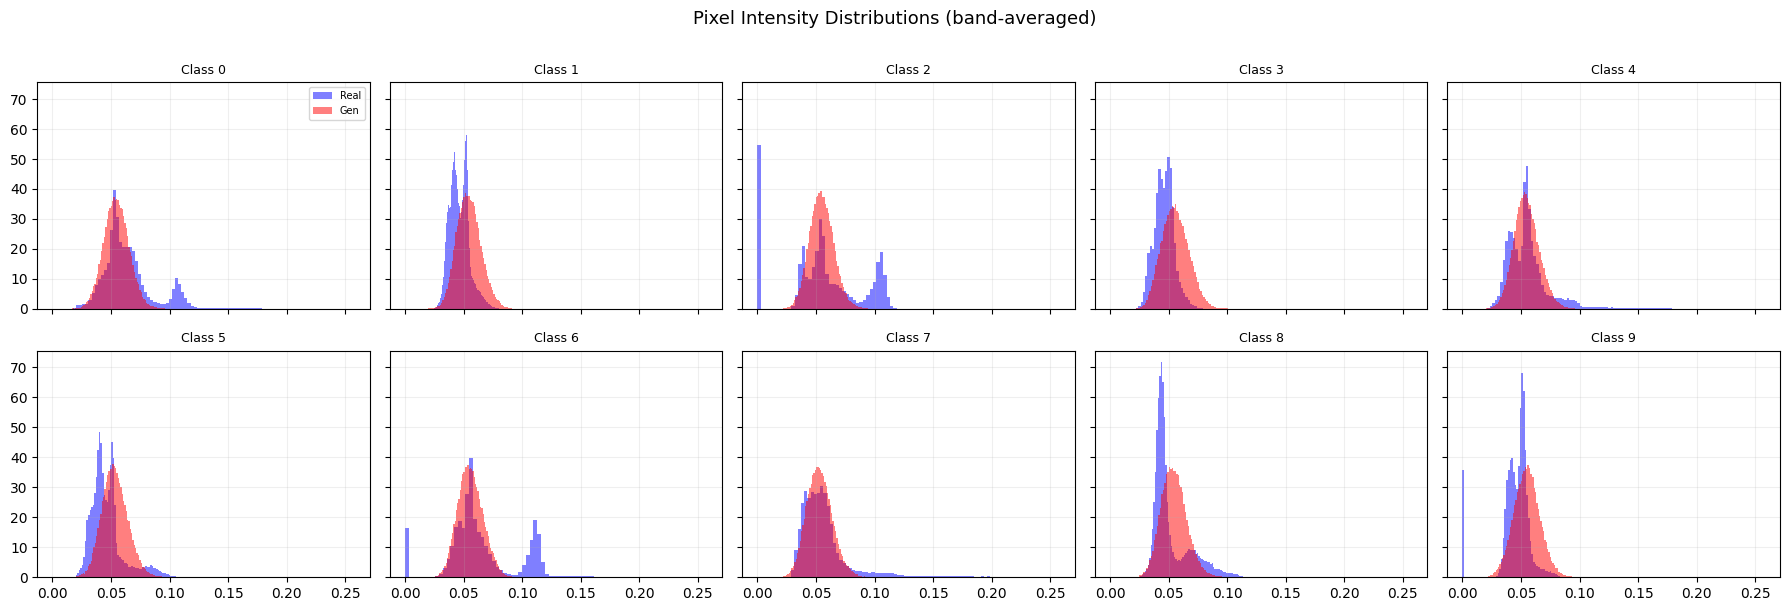

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharex=True, sharey=True)

for cls in range(10):
    ax = axes[cls // 5, cls % 5]

    # Collect pixel means from a few images
    real_dir = DATA_DIR / "evaluation" / str(cls)
    real_files = sorted(real_dir.glob("*.npy"))[:5]
    real_pixels = np.concatenate([load_image_normalized(f).mean(axis=-1).ravel() for f in real_files])

    gen_dir = RESULTS_DIR / "generated" / str(cls)
    gen_files = sorted(gen_dir.glob("*.npy"))[:5]
    gen_pixels = np.concatenate([load_image_normalized(f).mean(axis=-1).ravel() for f in gen_files])

    ax.hist(real_pixels, bins=80, alpha=0.5, density=True, color="blue", label="Real")
    ax.hist(gen_pixels, bins=80, alpha=0.5, density=True, color="red", label="Gen")
    ax.set_title(f"Class {cls}", fontsize=9)
    ax.grid(True, alpha=0.2)
    if cls == 0:
        ax.legend(fontsize=7)

fig.suptitle("Pixel Intensity Distributions (band-averaged)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pixel_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Summary

| Metric | Mean | Best Class | Worst Class |
|---|---|---|---|
| **Spectral FID** | 1.44 | Class 9 (0.27) | Class 3 (3.09) |
| **Spatial FID** | 105.91 | Class 8 (77.12) | Class 0 (132.75) |

**Key takeaways:**
- Spectral FID is excellent (mean 1.44), indicating the model faithfully reproduces spectral signatures across all disease severity levels.
- Spatial FID (~106) reflects the expected limitation of a 12-step normalizing flow — spatial fine structure is harder to capture than spectral statistics.
- Optimal temperature is consistently 1.05 across all classes.
- Classes 0, 2, 9 have the best spectral fidelity (<0.31), while classes 3 and 8 are harder (~3.0 and ~2.5).